# Paper Implementation: Isolation Forest
**Paper**: *Isolation Forest* — Liu, Ting & Zhou (2008)  
**Published**: IEEE International Conference on Data Mining (ICDM)  
**Generated**: 2025-03-15  

> **Warning:** This is an educational implementation for understanding the algorithm. For production use, prefer `sklearn.ensemble.IsolationForest`.

## Paper Overview

### Problem

Most anomaly detection methods work by building a profile of what "normal" data looks like and
then flagging points that deviate from that profile. This requires large amounts of normal data,
careful feature engineering, and distance or density calculations that scale poorly to high
dimensions. Can we detect anomalies *directly*, without ever modeling the normal class?

### Key Insight

Anomalies are **"few and different"**. Because they are rare and have attribute values that
differ significantly from normal instances, they are much easier to *isolate* when we randomly
partition the data. If you pick a random feature and a random split value, an anomaly will
tend to land alone in its own partition after very few splits, whereas normal points — being
clustered together — require many more splits before they are separated from their neighbors.

### Approach

1. **Build an ensemble of Isolation Trees (iTrees).** Each tree is constructed by:
   - Drawing a random subsample of the data (typically 256 points).
   - Recursively partitioning the subsample: at each node, pick a random feature and a random
     split value between the feature's min and max in the current subset.
   - Stopping when a node contains a single point, or when maximum depth is reached.

2. **Score each point** by its *average path length* across all trees. Shorter average paths
   indicate anomalies; longer paths indicate normal points.

3. **Normalize the score** using the expected average path length in a Binary Search Tree (BST)
   to obtain a value between 0 and 1, where scores near 1 indicate anomalies.

## Key Equations

### Path Length $h(x)$

The path length $h(x)$ is the number of edges (splits) that point $x$ traverses from the root
of an isolation tree until it reaches a leaf node (i.e., it is isolated). Shorter path lengths
correspond to points that are easier to isolate.

### Average Path Length of Unsuccessful Search in a BST: $c(n)$

To normalize path lengths, the paper uses the average path length of an unsuccessful search
in a Binary Search Tree built from $n$ records:

$$
c(n) = 2H(n-1) - \frac{2(n-1)}{n}
$$

where $H(i)$ is the harmonic number, approximated by:

$$
H(i) \approx \ln(i) + 0.5772156649 \quad \text{(Euler-Mascheroni constant)}
$$

### Anomaly Score: $s(x, n)$

The anomaly score for a point $x$ in a dataset of size $n$ is:

$$
s(x, n) = 2^{-\frac{E[h(x)]}{c(n)}}
$$

where $E[h(x)]$ is the average path length of $x$ across all isolation trees in the forest.

### Score Interpretation

| Score range | Interpretation |
|:-----------:|:---------------|
| $s \to 1$   | Very likely an **anomaly** (short average path length) |
| $s \approx 0.5$ | **Normal** — path length is close to the expected average |
| $s \to 0$   | **Very normal** — point is deeply embedded in a dense cluster |

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# For reproducibility
np.random.seed(42)

print("NumPy version:", np.__version__)

NumPy version: 2.4.2


In [2]:
class IsolationTreeNode:
    """A single node in an Isolation Tree."""

    def __init__(self, size, depth, left=None, right=None,
                 split_feature=None, split_value=None, is_leaf=False):
        self.size = size           # number of data points at this node
        self.depth = depth
        self.left = left
        self.right = right
        self.split_feature = split_feature
        self.split_value = split_value
        self.is_leaf = is_leaf


class IsolationTree:
    """
    An Isolation Tree (iTree) as described in Liu et al. (2008).

    The tree recursively partitions data by selecting a random feature
    and a random split value until each point is isolated or maximum
    depth is reached.
    """

    def __init__(self, max_depth):
        self.max_depth = max_depth
        self.root = None

    def fit(self, X, depth=0):
        """
        Recursively build the isolation tree.

        Parameters
        ----------
        X : np.ndarray of shape (n_samples, n_features)
            Data to partition.
        depth : int
            Current depth in the tree.

        Returns
        -------
        IsolationTreeNode
        """
        n_samples, n_features = X.shape

        # Base cases: isolate the point or hit max depth
        if n_samples <= 1 or depth >= self.max_depth:
            return IsolationTreeNode(size=n_samples, depth=depth, is_leaf=True)

        # Pick a random feature
        feature = np.random.randint(0, n_features)
        feat_min = X[:, feature].min()
        feat_max = X[:, feature].max()

        # If all values are the same for this feature, create a leaf
        if feat_min == feat_max:
            return IsolationTreeNode(size=n_samples, depth=depth, is_leaf=True)

        # Pick a random split value between min and max
        split_value = np.random.uniform(feat_min, feat_max)

        # Partition the data
        left_mask = X[:, feature] < split_value
        right_mask = ~left_mask

        left_child = self.fit(X[left_mask], depth + 1)
        right_child = self.fit(X[right_mask], depth + 1)

        node = IsolationTreeNode(
            size=n_samples,
            depth=depth,
            left=left_child,
            right=right_child,
            split_feature=feature,
            split_value=split_value,
            is_leaf=False,
        )
        if depth == 0:
            self.root = node
        return node

    def path_length(self, x, node=None, depth=0):
        """
        Compute the path length for a single point x.

        At leaf nodes, we add an adjustment term c(node.size) to account
        for the unbuilt subtree.

        Parameters
        ----------
        x : np.ndarray of shape (n_features,)
        node : IsolationTreeNode
        depth : int

        Returns
        -------
        float
            Path length (number of edges traversed, plus adjustment).
        """
        if node is None:
            node = self.root

        if node.is_leaf:
            # Adjustment for unbuilt subtree
            return depth + _c(node.size)

        if x[node.split_feature] < node.split_value:
            return self.path_length(x, node.left, depth + 1)
        else:
            return self.path_length(x, node.right, depth + 1)


print("IsolationTree class defined.")

IsolationTree class defined.


In [3]:
class IsolationForest:
    """
    Isolation Forest algorithm (Liu et al., 2008).

    Builds an ensemble of Isolation Trees, each trained on a random
    subsample. Anomaly scores are derived from average path lengths.

    Parameters
    ----------
    n_trees : int
        Number of isolation trees in the forest.
    sample_size : int
        Number of points to subsample for each tree.
    max_depth : int or None
        Maximum tree depth. If None, defaults to ceil(log2(sample_size)).
    """

    def __init__(self, n_trees=100, sample_size=256, max_depth=None):
        self.n_trees = n_trees
        self.sample_size = sample_size
        if max_depth is None:
            self.max_depth = int(np.ceil(np.log2(sample_size)))
        else:
            self.max_depth = max_depth
        self.trees = []

    def fit(self, X):
        """
        Build the isolation forest by training n_trees isolation trees.

        Parameters
        ----------
        X : np.ndarray of shape (n_samples, n_features)
        """
        self.trees = []
        n_samples = X.shape[0]
        for _ in range(self.n_trees):
            # Random subsample (without replacement if possible)
            if n_samples > self.sample_size:
                indices = np.random.choice(n_samples, self.sample_size, replace=False)
                X_sub = X[indices]
            else:
                X_sub = X.copy()

            tree = IsolationTree(max_depth=self.max_depth)
            tree.fit(X_sub)
            self.trees.append(tree)

        print(f"Fitted IsolationForest with {self.n_trees} trees, "
              f"sample_size={self.sample_size}, max_depth={self.max_depth}")

    def anomaly_score(self, X):
        """
        Compute the anomaly score s(x, n) for each point in X.

        s(x, n) = 2^(-E[h(x)] / c(sample_size))

        Parameters
        ----------
        X : np.ndarray of shape (n_samples, n_features)

        Returns
        -------
        np.ndarray of shape (n_samples,)
            Anomaly scores in [0, 1]. Higher means more anomalous.
        """
        n_samples = X.shape[0]
        avg_path_lengths = np.zeros(n_samples)

        for tree in self.trees:
            for i in range(n_samples):
                avg_path_lengths[i] += tree.path_length(X[i])

        avg_path_lengths /= len(self.trees)

        # Normalize using c(sample_size)
        c_n = _c(self.sample_size)
        scores = np.power(2, -avg_path_lengths / c_n)
        return scores

    def predict(self, X, threshold=0.5):
        """
        Predict anomaly labels.

        Parameters
        ----------
        X : np.ndarray of shape (n_samples, n_features)
        threshold : float
            Points with anomaly score >= threshold are labeled as anomalies.

        Returns
        -------
        np.ndarray of shape (n_samples,)
            1 for anomaly, 0 for normal.
        """
        scores = self.anomaly_score(X)
        return (scores >= threshold).astype(int)


print("IsolationForest class defined.")

IsolationForest class defined.


In [4]:
def _c(n):
    """
    Average path length of unsuccessful search in a BST (Eq. 1 in the paper).

    c(n) = 2*H(n-1) - 2*(n-1)/n

    where H(i) ~ ln(i) + 0.5772156649 (Euler-Mascheroni constant).

    Parameters
    ----------
    n : int
        Number of data points.

    Returns
    -------
    float
        Average path length.
    """
    if n <= 1:
        return 0.0
    if n == 2:
        return 1.0
    euler_mascheroni = 0.5772156649
    harmonic = np.log(n - 1) + euler_mascheroni
    return 2.0 * harmonic - 2.0 * (n - 1) / n


# Quick sanity check
print(f"c(2)   = {_c(2):.4f}  (expected: 1.0)")
print(f"c(4)   = {_c(4):.4f}")
print(f"c(256) = {_c(256):.4f}")
print(f"c(1)   = {_c(1):.4f}  (expected: 0.0)")

c(2)   = 1.0000  (expected: 1.0)
c(4)   = 1.8517
c(256) = 10.2448
c(1)   = 0.0000  (expected: 0.0)


## Toy Example: Detecting Anomalies in Sensor Data

We create a synthetic 2D dataset that simulates sensor readings:
- **Normal points** are drawn from a bivariate normal distribution centered at the origin.
- **Anomaly points** are scattered far from the center, simulating faulty sensor readings.

Dataset: 315 points (300 normal, 15 anomalies)
Feature ranges: x1 [-5.65, 4.58], x2 [-5.39, 5.31]


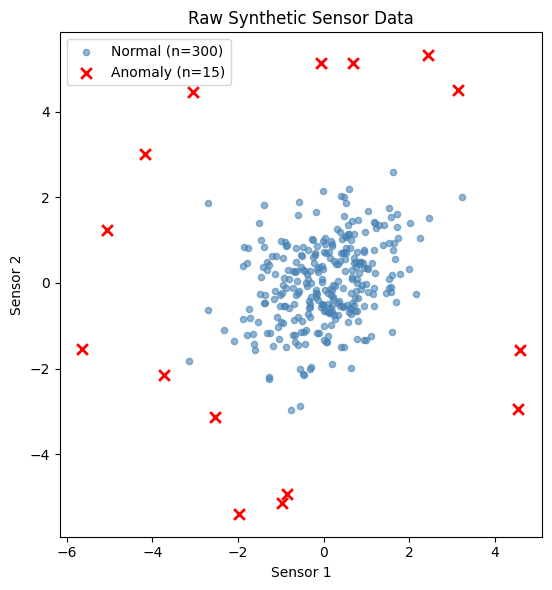

In [5]:
np.random.seed(42)

# --- Normal data: 300 points from a bivariate normal ---
n_normal = 300
mean_normal = [0, 0]
cov_normal = [[1.0, 0.3],
              [0.3, 1.0]]
X_normal = np.random.multivariate_normal(mean_normal, cov_normal, n_normal)

# --- Anomaly data: 15 points scattered far from center ---
n_anomaly = 15
# Generate anomalies in a ring around the normal cluster
angles = np.random.uniform(0, 2 * np.pi, n_anomaly)
radii = np.random.uniform(4, 6, n_anomaly)
X_anomaly = np.column_stack([radii * np.cos(angles),
                              radii * np.sin(angles)])

# Combine into a single dataset
X = np.vstack([X_normal, X_anomaly])
# True labels: 0 = normal, 1 = anomaly
y_true = np.array([0] * n_normal + [1] * n_anomaly)

print(f"Dataset: {X.shape[0]} points ({n_normal} normal, {n_anomaly} anomalies)")
print(f"Feature ranges: x1 [{X[:,0].min():.2f}, {X[:,0].max():.2f}], "
      f"x2 [{X[:,1].min():.2f}, {X[:,1].max():.2f}]")

# --- Plot raw data ---
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_normal[:, 0], X_normal[:, 1], c="steelblue", s=20,
           alpha=0.6, label=f"Normal (n={n_normal})")
ax.scatter(X_anomaly[:, 0], X_anomaly[:, 1], c="red", s=60,
           marker="x", linewidths=2, label=f"Anomaly (n={n_anomaly})")
ax.set_xlabel("Sensor 1")
ax.set_ylabel("Sensor 2")
ax.set_title("Raw Synthetic Sensor Data")
ax.legend()
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

Fitted IsolationForest with 100 trees, sample_size=256, max_depth=8


Score range: [0.3705, 0.7485]
Mean score (normal):  0.4132
Mean score (anomaly): 0.6895


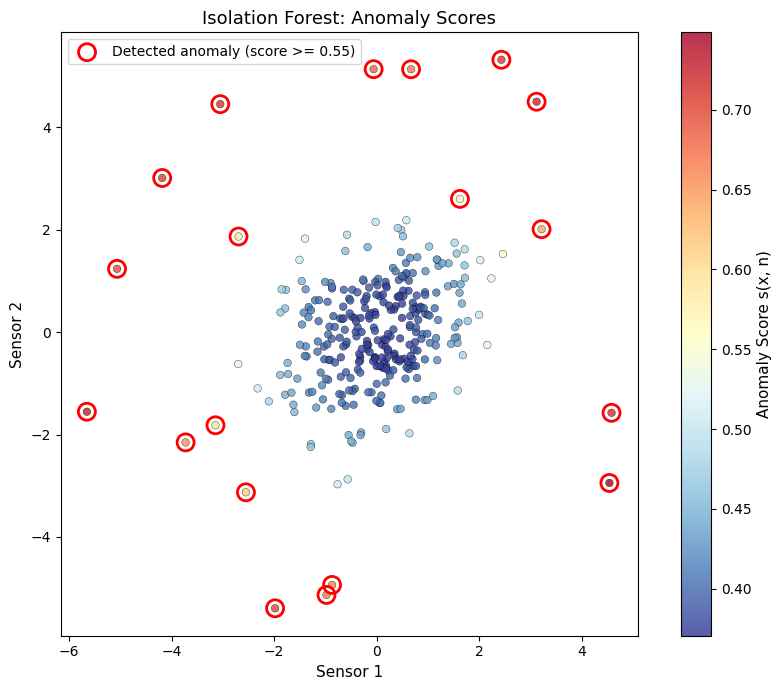

In [6]:
np.random.seed(42)

# --- Fit the Isolation Forest ---
iforest = IsolationForest(n_trees=100, sample_size=256, max_depth=None)
iforest.fit(X)

# --- Compute anomaly scores ---
scores = iforest.anomaly_score(X)
print(f"Score range: [{scores.min():.4f}, {scores.max():.4f}]")
print(f"Mean score (normal):  {scores[:n_normal].mean():.4f}")
print(f"Mean score (anomaly): {scores[n_normal:].mean():.4f}")

# --- Scatter plot colored by anomaly score ---
fig, ax = plt.subplots(figsize=(9, 7))
scatter = ax.scatter(X[:, 0], X[:, 1], c=scores, cmap="RdYlBu_r",
                     s=30, alpha=0.8, edgecolors="k", linewidths=0.3)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Anomaly Score s(x, n)", fontsize=11)

# Mark detected anomalies (score >= 0.55) with red circles
threshold = 0.55
y_pred = (scores >= threshold).astype(int)
detected_mask = y_pred == 1
ax.scatter(X[detected_mask, 0], X[detected_mask, 1],
           facecolors="none", edgecolors="red", s=150, linewidths=2,
           label=f"Detected anomaly (score >= {threshold})")

ax.set_xlabel("Sensor 1", fontsize=11)
ax.set_ylabel("Sensor 2", fontsize=11)
ax.set_title("Isolation Forest: Anomaly Scores", fontsize=13)
ax.legend(loc="upper left", fontsize=10)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

In [7]:
# --- Evaluate detection quality ---

# Use threshold = 0.55 (slightly above the 0.5 "normal" baseline)
threshold = 0.55
y_pred = (scores >= threshold).astype(int)

# Confusion-matrix-style results
true_positives = np.sum((y_pred == 1) & (y_true == 1))
false_positives = np.sum((y_pred == 1) & (y_true == 0))
true_negatives = np.sum((y_pred == 0) & (y_true == 0))
false_negatives = np.sum((y_pred == 0) & (y_true == 1))

print("=" * 50)
print(f"Detection Results (threshold = {threshold})")
print("=" * 50)
print(f"")
print(f"                  Predicted Normal  Predicted Anomaly")
print(f"  Actual Normal   {true_negatives:>15d}  {false_positives:>17d}")
print(f"  Actual Anomaly  {false_negatives:>15d}  {true_positives:>17d}")
print(f"")
print(f"True anomalies found (recall):    {true_positives}/{n_anomaly} "
      f"({100*true_positives/n_anomaly:.1f}%)")
print(f"False positives:                  {false_positives}/{n_normal} "
      f"({100*false_positives/n_normal:.1f}%)")

if (true_positives + false_positives) > 0:
    precision = true_positives / (true_positives + false_positives)
    print(f"Precision:                        {precision:.3f}")

recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
print(f"Recall:                           {recall:.3f}")

print(f"")
print(f"Average anomaly score (normal points):  {scores[:n_normal].mean():.4f}")
print(f"Average anomaly score (anomaly points): {scores[n_normal:].mean():.4f}")
print(f"Score gap:                              "
      f"{scores[n_normal:].mean() - scores[:n_normal].mean():.4f}")

Detection Results (threshold = 0.55)

                  Predicted Normal  Predicted Anomaly
  Actual Normal               296                  4
  Actual Anomaly                0                 15

True anomalies found (recall):    15/15 (100.0%)
False positives:                  4/300 (1.3%)
Precision:                        0.789
Recall:                           1.000

Average anomaly score (normal points):  0.4132
Average anomaly score (anomaly points): 0.6895
Score gap:                              0.2763


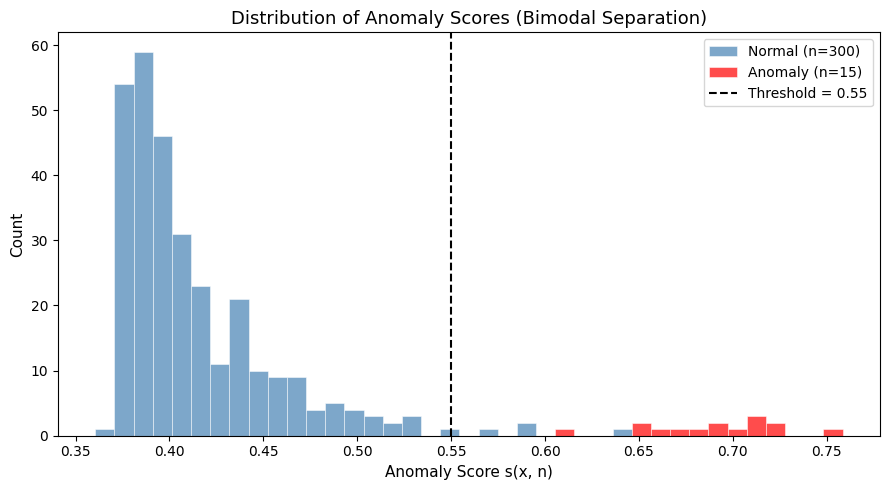

Normal scores  - mean: 0.4132, std: 0.0418
Anomaly scores - mean: 0.6895, std: 0.0341


In [8]:
# --- Score distribution histogram ---
fig, ax = plt.subplots(figsize=(9, 5))

bins = np.linspace(scores.min() - 0.01, scores.max() + 0.01, 40)

ax.hist(scores[:n_normal], bins=bins, alpha=0.7, color="steelblue",
        label=f"Normal (n={n_normal})", edgecolor="white", linewidth=0.5)
ax.hist(scores[n_normal:], bins=bins, alpha=0.7, color="red",
        label=f"Anomaly (n={n_anomaly})", edgecolor="white", linewidth=0.5)

ax.axvline(x=threshold, color="black", linestyle="--", linewidth=1.5,
           label=f"Threshold = {threshold}")

ax.set_xlabel("Anomaly Score s(x, n)", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("Distribution of Anomaly Scores (Bimodal Separation)", fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"Normal scores  - mean: {scores[:n_normal].mean():.4f}, "
      f"std: {scores[:n_normal].std():.4f}")
print(f"Anomaly scores - mean: {scores[n_normal:].mean():.4f}, "
      f"std: {scores[n_normal:].std():.4f}")

## Limitations & Notes

### Implementation Limitations

- **Pure Python/NumPy only.** This implementation does not use Cython or C extensions.
  Each tree traversal is done point-by-point in Python, making it significantly slower
  than optimized libraries for large datasets.

- **Production alternative.** The `sklearn.ensemble.IsolationForest` implementation uses
  optimized C code (via Cython) and supports additional features such as warm starting,
  contamination-based threshold selection, and the Extended Isolation Forest variant
  (which uses random hyperplanes instead of axis-aligned splits).

### Extensions Mentioned in the Paper

- **SCiForest (Subspace Clustering Isolation Forest):** An extension proposed by the same
  authors that uses hyperplane splits (linear combinations of features) instead of
  axis-aligned splits. This helps detect anomalies in the presence of clustered anomalies
  or axis-aligned normal clusters.

### What Is Not Covered Here

- **Benchmark experiments.** The paper evaluates the algorithm on several real-world datasets
  including KDD Cup 1999 (network intrusion detection), HTTP data, ForestCover, Mulcross,
  and others. These experiments demonstrate that Isolation Forest achieves competitive AUC
  scores with substantially lower computational cost than methods like LOF, Random Forests,
  and one-class SVMs.

- **Detailed complexity analysis.** The paper shows that Isolation Forest has linear time
  complexity $O(t \cdot \psi \cdot \log \psi)$ for training (where $t$ is the number of trees
  and $\psi$ is the subsample size) and $O(n \cdot t \cdot \log \psi)$ for scoring, making it
  highly scalable.